In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
PyTorch: 2.13.0+cpu


In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

In [3]:
data_file = "quantum_encoded_healthcare_data.xlsx"
quantum_model_file = "variational_quantum_model_state.pt"

required_files = [
    data_file,
    quantum_model_file
]

for file_name in required_files:
    if not os.path.exists(file_name):
        raise FileNotFoundError(
            f"{file_name} was not found. "
            "Place it in the notebook folder."
        )

print("All required files are available.")

All required files are available.


In [4]:
X_train_df = pd.read_excel(
    data_file,
    sheet_name="X_Train_Quantum"
)

X_test_df = pd.read_excel(
    data_file,
    sheet_name="X_Test_Quantum"
)

y_train_df = pd.read_excel(
    data_file,
    sheet_name="Y_Train"
)

y_test_df = pd.read_excel(
    data_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    data_file,
    sheet_name="Class_Mapping"
)

print("Training features:", X_train_df.shape)
print("Testing features:", X_test_df.shape)
print("Training targets:", y_train_df.shape)
print("Testing targets:", y_test_df.shape)

display(class_mapping)

Training features: (400, 4)
Testing features: (100, 4)
Training targets: (400, 2)
Testing targets: (100, 2)


,encoded_label,historical_medication_class
0,0,Acid-suppression class A
1,1,Acid-suppression class B
2,2,Antidiabetic class A
3,3,Antidiabetic class B
4,4,Antihistamine class A
5,5,Antihistamine class B
6,6,Antihypertensive class A
7,7,Antihypertensive class B
8,8,Bronchodilator class
9,9,Controller inhaler class


In [5]:
target_column = "encoded_target"

if target_column not in y_train_df.columns:
    raise KeyError(
        f"{target_column} is missing from Y_Train. "
        f"Available columns: {y_train_df.columns.tolist()}"
    )

X_full_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)

y_full_train = y_train_df[
    target_column
].to_numpy(dtype=np.int64)

y_test = y_test_df[
    target_column
].to_numpy(dtype=np.int64)

n_qubits = X_full_train.shape[1]
class_ids = np.sort(np.unique(y_full_train))
n_classes = len(class_ids)

print("Number of qubits:", n_qubits)
print("Number of classes:", n_classes)

assert n_qubits == 4
assert n_classes == 12

Number of qubits: 4
Number of classes: 12


In [6]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_full_train
)

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training: (320, 4)
Validation: (80, 4)
Testing: (100, 4)


In [7]:
n_quantum_layers = 2
wires = list(range(n_qubits))

quantum_device = qml.device(
    "default.qubit",
    wires=n_qubits
)

@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def variational_quantum_circuit(inputs, weights):
    qml.AngleEmbedding(
        features=inputs,
        wires=wires,
        rotation="Y"
    )

    qml.StronglyEntanglingLayers(
        weights=weights,
        wires=wires
    )

    return [
        qml.expval(qml.PauliZ(wire))
        for wire in wires
    ]


weight_shapes = {
    "weights": (
        n_quantum_layers,
        n_qubits,
        3
    )
}

In [8]:
class HybridVariationalQuantumClassifier(nn.Module):
    def __init__(self, n_classes, weight_shapes):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            variational_quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            n_classes
        )

    def forward(self, inputs):
        quantum_features = self.quantum_layer(inputs)
        return self.output_layer(quantum_features)


quantum_model = HybridVariationalQuantumClassifier(
    n_classes=n_classes,
    weight_shapes=weight_shapes
)

print(quantum_model)

HybridVariationalQuantumClassifier(
  (quantum_layer): <Quantum Torch Layer: func=variational_quantum_circuit>
  (output_layer): Linear(in_features=4, out_features=12, bias=True)
)


In [9]:
try:
    checkpoint = torch.load(
        quantum_model_file,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        quantum_model_file,
        map_location="cpu"
    )

quantum_model.load_state_dict(
    checkpoint["model_state_dict"]
)

quantum_model.eval()

print("Day 19 quantum model loaded successfully.")

Day 19 quantum model loaded successfully.


In [10]:
classical_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

classical_model.fit(
    X_train,
    y_train
)

print("Classical Random Forest trained.")

Classical Random Forest trained.


In [11]:
def get_quantum_probabilities(model, features):
    feature_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    model.eval()

    with torch.no_grad():
        logits = model(feature_tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    return probabilities

In [12]:
def align_classical_probabilities(
    model,
    features,
    all_class_ids
):
    raw_probabilities = model.predict_proba(features)

    aligned_probabilities = np.zeros(
        (len(features), len(all_class_ids)),
        dtype=np.float64
    )

    class_to_position = {
        class_id: position
        for position, class_id
        in enumerate(all_class_ids)
    }

    for source_position, class_id in enumerate(
        model.classes_
    ):
        target_position = class_to_position[class_id]

        aligned_probabilities[:, target_position] = (
            raw_probabilities[:, source_position]
        )

    return aligned_probabilities

In [13]:
quantum_validation_probabilities = (
    get_quantum_probabilities(
        quantum_model,
        X_validation
    )
)

classical_validation_probabilities = (
    align_classical_probabilities(
        classical_model,
        X_validation,
        class_ids
    )
)

print(
    "Quantum validation probabilities:",
    quantum_validation_probabilities.shape
)

print(
    "Classical validation probabilities:",
    classical_validation_probabilities.shape
)

Quantum validation probabilities: (80, 12)
Classical validation probabilities: (80, 12)


In [14]:
weight_search_results = []

for quantum_weight in np.arange(0.0, 1.01, 0.05):
    classical_weight = 1.0 - quantum_weight

    hybrid_validation_probabilities = (
        quantum_weight
        * quantum_validation_probabilities
        +
        classical_weight
        * classical_validation_probabilities
    )

    hybrid_validation_predictions = np.argmax(
        hybrid_validation_probabilities,
        axis=1
    )

    validation_accuracy = accuracy_score(
        y_validation,
        hybrid_validation_predictions
    )

    _, _, validation_macro_f1, _ = (
        precision_recall_fscore_support(
            y_validation,
            hybrid_validation_predictions,
            average="macro",
            zero_division=0
        )
    )

    weight_search_results.append({
        "quantum_weight": quantum_weight,
        "classical_weight": classical_weight,
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1
    })

weight_search_df = pd.DataFrame(weight_search_results)

best_weight_row = (
    weight_search_df
    .sort_values(
        by=[
            "validation_macro_f1",
            "validation_accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)

best_quantum_weight = float(
    best_weight_row["quantum_weight"]
)

best_classical_weight = float(
    best_weight_row["classical_weight"]
)

print("Best quantum weight:", best_quantum_weight)
print("Best classical weight:", best_classical_weight)
print(
    "Best validation macro F1:",
    round(best_weight_row["validation_macro_f1"], 4)
)

display(
    weight_search_df.sort_values(
        "validation_macro_f1",
        ascending=False
    ).head(10)
)

Best quantum weight: 0.4
Best classical weight: 0.6
Best validation macro F1: 0.306


,quantum_weight,classical_weight,validation_accuracy,validation_macro_f1
8,0.40,0.60,0.3125,0.306036
5,0.25,0.75,0.3125,0.304675
6,0.30,0.70,0.3125,0.304675
4,0.20,0.80,0.3125,0.304675
11,0.55,0.45,0.3125,0.300244
12,0.60,0.40,0.3125,0.298370
3,0.15,0.85,0.3000,0.295266
1,0.05,0.95,0.3000,0.295266
2,0.10,0.90,0.3000,0.295266
9,0.45,0.55,0.3000,0.293704


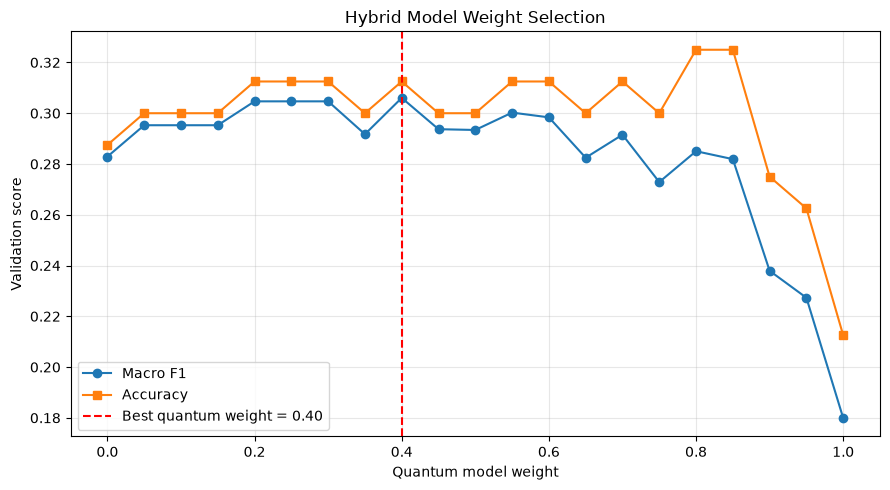

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    weight_search_df["quantum_weight"],
    weight_search_df["validation_macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    weight_search_df["quantum_weight"],
    weight_search_df["validation_accuracy"],
    marker="s",
    label="Accuracy"
)

plt.axvline(
    best_quantum_weight,
    color="red",
    linestyle="--",
    label=f"Best quantum weight = {best_quantum_weight:.2f}"
)

plt.xlabel("Quantum model weight")
plt.ylabel("Validation score")
plt.title("Hybrid Model Weight Selection")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
quantum_test_probabilities = get_quantum_probabilities(
    quantum_model,
    X_test
)

classical_test_probabilities = (
    align_classical_probabilities(
        classical_model,
        X_test,
        class_ids
    )
)

hybrid_test_probabilities = (
    best_quantum_weight
    * quantum_test_probabilities
    +
    best_classical_weight
    * classical_test_probabilities
)
hybrid_test_probabilities = (
    hybrid_test_probabilities
    /
    hybrid_test_probabilities.sum(
        axis=1,
        keepdims=True
    )
)

quantum_test_predictions = np.argmax(
    quantum_test_probabilities,
    axis=1
)

classical_test_predictions = np.argmax(
    classical_test_probabilities,
    axis=1
)

hybrid_test_predictions = np.argmax(
    hybrid_test_probabilities,
    axis=1
)

print("Hybrid predictions:", hybrid_test_predictions.shape)

Hybrid predictions: (100,)


In [17]:
def calculate_metrics(
    model_name,
    y_true,
    predictions,
    probabilities
):
    accuracy = accuracy_score(
        y_true,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        predictions
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    top_2 = np.argsort(
        probabilities,
        axis=1
    )[:, -2:]

    top_3 = np.argsort(
        probabilities,
        axis=1
    )[:, -3:]

    top_2_accuracy = np.mean([
        actual in predicted
        for actual, predicted
        in zip(y_true, top_2)
    ])

    top_3_accuracy = np.mean([
        actual in predicted
        for actual, predicted
        in zip(y_true, top_3)
    ])

    return {
        "model": model_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "top_2_accuracy": top_2_accuracy,
        "top_3_accuracy": top_3_accuracy
    }

In [18]:
comparison_results = [
    calculate_metrics(
        "Variational Quantum Model",
        y_test,
        quantum_test_predictions,
        quantum_test_probabilities
    ),

    calculate_metrics(
        "Classical Random Forest",
        y_test,
        classical_test_predictions,
        classical_test_probabilities
    ),

    calculate_metrics(
        "Hybrid Quantum-Classical Model",
        y_test,
        hybrid_test_predictions,
        hybrid_test_probabilities
    )
]

comparison_df = pd.DataFrame(comparison_results)

display(
    comparison_df.sort_values(
        "macro_f1",
        ascending=False
    )
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_2_accuracy,top_3_accuracy
1,Classical Random Forest,0.34,0.34752,0.317325,0.34752,0.321544,0.317661,0.69,0.76
2,Hybrid Quantum-Classical Model,0.32,0.32543,0.313652,0.32543,0.313136,0.310143,0.66,0.76
0,Variational Quantum Model,0.25,0.23793,0.218117,0.23793,0.211216,0.216943,0.53,0.67


In [19]:
hybrid_report_df = pd.DataFrame(
    classification_report(
        y_test,
        hybrid_test_predictions,
        labels=class_ids,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(hybrid_report_df)

,precision,recall,f1-score,support
0,0.166667,0.125000,0.142857,8.00
1,0.285714,0.285714,0.285714,7.00
2,0.454545,0.555556,0.500000,9.00
3,0.428571,0.375000,0.400000,8.00
4,0.142857,0.100000,0.117647,10.00
5,0.200000,0.125000,0.153846,8.00
6,0.444444,0.444444,0.444444,9.00
7,0.500000,0.444444,0.470588,9.00
8,0.333333,0.428571,0.375000,7.00
9,0.166667,0.200000,0.181818,10.00


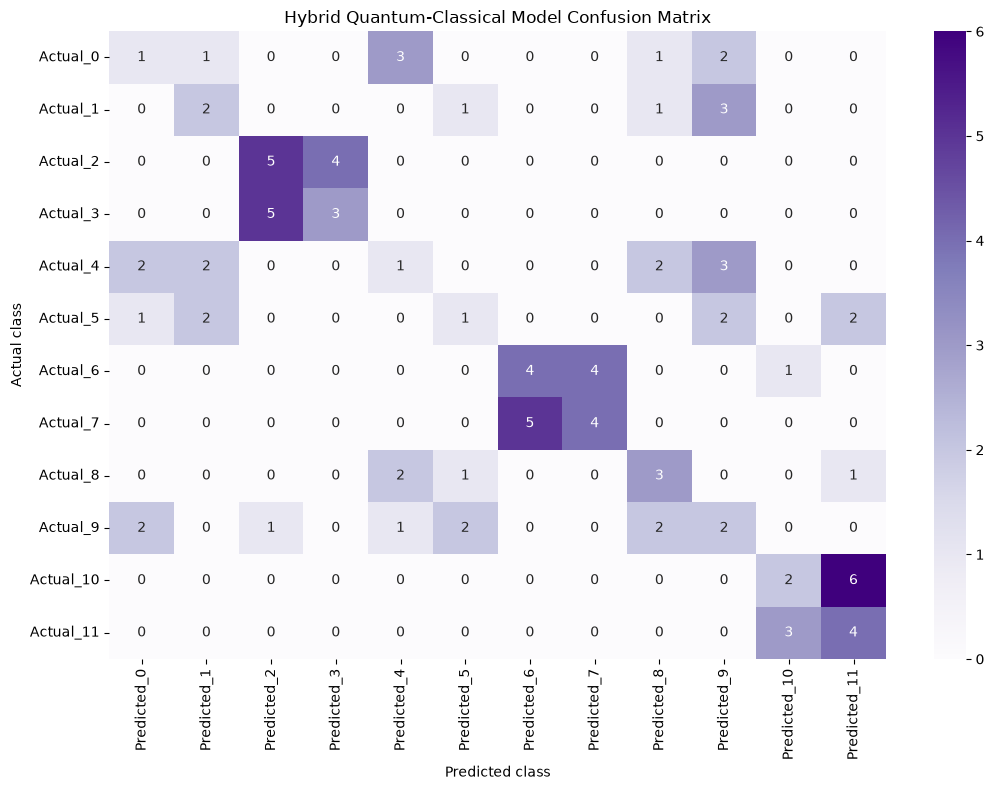

In [20]:
hybrid_confusion = confusion_matrix(
    y_test,
    hybrid_test_predictions,
    labels=class_ids
)

hybrid_confusion_df = pd.DataFrame(
    hybrid_confusion,
    index=[
        f"Actual_{class_id}"
        for class_id in class_ids
    ],
    columns=[
        f"Predicted_{class_id}"
        for class_id in class_ids
    ]
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    hybrid_confusion_df,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Hybrid Quantum-Classical Model Confusion Matrix"
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

In [21]:
class_mapping.columns = (
    class_mapping.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

encoded_candidates = [
    "encoded_target",
    "encoded_label",
    "class_id",
    "target_encoded",
    "encoded_class"
]

medicine_candidates = [
    "historical_medication_class",
    "medication_class",
    "class_name",
    "original_class",
    "medicine_class"
]

encoded_column = next(
    (
        column for column in encoded_candidates
        if column in class_mapping.columns
    ),
    None
)

medicine_column = next(
    (
        column for column in medicine_candidates
        if column in class_mapping.columns
    ),
    None
)

if encoded_column is None or medicine_column is None:
    raise KeyError(
        "Class-mapping columns could not be detected. "
        f"Available columns: {class_mapping.columns.tolist()}"
    )

mapping_dictionary = {
    int(encoded_value): str(medicine_name)
    for encoded_value, medicine_name in zip(
        class_mapping[encoded_column],
        class_mapping[medicine_column]
    )
}

print("Mapped classes:", len(mapping_dictionary))
print(mapping_dictionary)

Mapped classes: 12
{0: 'Acid-suppression class A', 1: 'Acid-suppression class B', 2: 'Antidiabetic class A', 3: 'Antidiabetic class B', 4: 'Antihistamine class A', 5: 'Antihistamine class B', 6: 'Antihypertensive class A', 7: 'Antihypertensive class B', 8: 'Bronchodilator class', 9: 'Controller inhaler class', 10: 'Lipid-lowering class A', 11: 'Lipid-lowering class B'}


In [22]:
top_3_class_ids = np.argsort(
    hybrid_test_probabilities,
    axis=1
)[:, -3:][:, ::-1]

recommendation_results = pd.DataFrame({
    "actual_encoded_target": y_test,
    "predicted_encoded_target": hybrid_test_predictions,

    "actual_medication_class": [
        mapping_dictionary.get(
            int(class_id),
            f"Class_{class_id}"
        )
        for class_id in y_test
    ],

    "recommended_medication_class": [
        mapping_dictionary.get(
            int(class_id),
            f"Class_{class_id}"
        )
        for class_id in hybrid_test_predictions
    ],

    "recommendation_confidence": np.max(
        hybrid_test_probabilities,
        axis=1
    ),

    "recommendation_correct": (
        y_test == hybrid_test_predictions
    )
})

for rank in range(3):
    ranked_ids = top_3_class_ids[:, rank]

    recommendation_results[
        f"rank_{rank + 1}_medication_class"
    ] = [
        mapping_dictionary.get(
            int(class_id),
            f"Class_{class_id}"
        )
        for class_id in ranked_ids
    ]

    recommendation_results[
        f"rank_{rank + 1}_score"
    ] = [
        hybrid_test_probabilities[
            row_index,
            class_id
        ]
        for row_index, class_id
        in enumerate(ranked_ids)
    ]

display(recommendation_results.head(10))

,actual_encoded_target,predicted_encoded_target,actual_medication_class,recommended_medication_class,recommendation_confidence,recommendation_correct,rank_1_medication_class,rank_1_score,rank_2_medication_class,rank_2_score,rank_3_medication_class,rank_3_score
0,9,0,Controller inhaler class,Acid-suppression class A,0.204908,False,Acid-suppression class A,0.204908,Acid-suppression class B,0.192691,Antihistamine class A,0.147528
1,2,3,Antidiabetic class A,Antidiabetic class B,0.384625,False,Antidiabetic class B,0.384625,Antidiabetic class A,0.370049,Lipid-lowering class A,0.054197
2,10,10,Lipid-lowering class A,Lipid-lowering class A,0.406721,True,Lipid-lowering class A,0.406721,Lipid-lowering class B,0.400737,Antihistamine class B,0.044279
3,10,11,Lipid-lowering class A,Lipid-lowering class B,0.445661,False,Lipid-lowering class B,0.445661,Lipid-lowering class A,0.175495,Antihypertensive class A,0.153377
4,5,0,Antihistamine class B,Acid-suppression class A,0.198123,False,Acid-suppression class A,0.198123,Bronchodilator class,0.176424,Antihistamine class A,0.156921
5,8,11,Bronchodilator class,Lipid-lowering class B,0.191729,False,Lipid-lowering class B,0.191729,Bronchodilator class,0.122928,Antidiabetic class A,0.115021
6,7,6,Antihypertensive class B,Antihypertensive class A,0.413230,False,Antihypertensive class A,0.413230,Antihypertensive class B,0.387472,Antidiabetic class B,0.049697
7,3,3,Antidiabetic class B,Antidiabetic class B,0.452570,True,Antidiabetic class B,0.452570,Antidiabetic class A,0.211477,Antihistamine class A,0.069128
8,5,11,Antihistamine class B,Lipid-lowering class B,0.304111,False,Lipid-lowering class B,0.304111,Lipid-lowering class A,0.192129,Bronchodilator class,0.131913
9,6,10,Antihypertensive class A,Lipid-lowering class A,0.177374,False,Lipid-lowering class A,0.177374,Antihypertensive class B,0.145274,Lipid-lowering class B,0.117593


In [23]:
probability_sums = hybrid_test_probabilities.sum(axis=1)

print(
    "Minimum probability sum:",
    probability_sums.min()
)

print(
    "Maximum probability sum:",
    probability_sums.max()
)

assert np.allclose(
    probability_sums,
    1.0,
    atol=1e-6
)

assert (
    recommendation_results[
        "rank_1_score"
    ]
    >=
    recommendation_results[
        "rank_2_score"
    ]
).all()

assert (
    recommendation_results[
        "rank_2_score"
    ]
    >=
    recommendation_results[
        "rank_3_score"
    ]
).all()

print("Recommendation ranking is valid.")

Minimum probability sum: 0.9999999999999996
Maximum probability sum: 1.0000000000000004
Recommendation ranking is valid.


In [24]:
import joblib

classical_model_file = (
    "hybrid_quantum_classical_random_forest.pkl"
)

joblib.dump(
    {
        "classical_model": classical_model,
        "quantum_weight": best_quantum_weight,
        "classical_weight": best_classical_weight,
        "class_ids": class_ids,
        "class_mapping": mapping_dictionary,
        "random_state": RANDOM_STATE
    },
    classical_model_file
)

print("Saved:", classical_model_file)

Saved: hybrid_quantum_classical_random_forest.pkl


In [25]:
results_file = (
    "hybrid_quantum_classical_recommendation_results.xlsx"
)

configuration_file = (
    "hybrid_quantum_classical_configuration.json"
)

configuration = {
    "model_type": "Weighted Hybrid Quantum-Classical Ensemble",
    "quantum_component": "Variational Quantum Classifier",
    "classical_component": "Random Forest Classifier",
    "number_of_qubits": int(n_qubits),
    "number_of_classes": int(n_classes),
    "quantum_weight": best_quantum_weight,
    "classical_weight": best_classical_weight,
    "weight_selection_metric": "validation_macro_f1",
    "random_state": RANDOM_STATE
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    results_file,
    engine="openpyxl"
) as writer:

    comparison_df.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False
    )

    weight_search_df.to_excel(
        writer,
        sheet_name="Weight_Search",
        index=False
    )

    recommendation_results.to_excel(
        writer,
        sheet_name="Recommendations",
        index=False
    )

    hybrid_report_df.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    hybrid_confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    class_mapping.to_excel(
        writer,
        sheet_name="Class_Mapping",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved results:", results_file)
print("Saved configuration:", configuration_file)

Saved results: hybrid_quantum_classical_recommendation_results.xlsx
Saved configuration: hybrid_quantum_classical_configuration.json


In [26]:
output_files = [
    classical_model_file,
    results_file,
    configuration_file
]

for output_file in output_files:
    print(
        output_file,
        "exists:",
        os.path.exists(output_file)
    )

hybrid_row = comparison_df[
    comparison_df["model"]
    == "Hybrid Quantum-Classical Model"
].iloc[0]

print(
    "\nHybrid accuracy:",
    round(hybrid_row["accuracy"], 4)
)

print(
    "Hybrid macro F1:",
    round(hybrid_row["macro_f1"], 4)
)

print(
    "Hybrid top-3 accuracy:",
    round(hybrid_row["top_3_accuracy"], 4)
)

hybrid_quantum_classical_random_forest.pkl exists: True
hybrid_quantum_classical_recommendation_results.xlsx exists: True
hybrid_quantum_classical_configuration.json exists: True

Hybrid accuracy: 0.32
Hybrid macro F1: 0.3131
Hybrid top-3 accuracy: 0.76
